# Proiect Econometrie Avansată — Predicția Bolii Cardiace
## Dataset: Heart Disease UCI

**Sursa datelor:** [Heart Disease UCI — Kaggle](https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data)

---

## Despre proiect

Acest proiect aplică metode de econometrie și învățare automată pe un dataset clinic ce cuprinde informații despre pacienți și diagnostice cardiologice. Scopul este construirea unui model care să prezică dacă un pacient suferă de o boală cardiacă, pornind de la variabile clinice precum vârsta, tensiunea, colesterolul, ritmul cardiac maxim atins la efort și rezultatele unor investigații specifice.

Datasetul provine din baza **UCI Heart Disease** și conține aproximativ 920 de pacienți colectați din mai multe spitale. Variabila țintă originală (`target`) ia valori de la **0 la 4**, unde **0 înseamnă pacient sănătos**, iar valorile **1–4 reprezintă grade de severitate crescătoare** ale bolii cardiace.

## De ce este utilă această analiză?

Un astfel de model are aplicații concrete:

- **Screening medical:** într-un spital cu resurse limitate, modelul poate fi folosit ca primă filtră pentru a identifica pacienții cu risc crescut, care merg apoi la investigații aprofundate.
- **Triere (triage):** orientează pacienții către specialistul potrivit în funcție de probabilitatea de boală.
- **Interpretarea factorilor de risc:** prin coeficienții regresiei logistice se pot identifica variabilele care influențează cel mai mult riscul cardiac, ceea ce ajută la educarea pacienților și la prevenție.

## Structura proiectului

Proiectul este organizat în două părți mari, care folosesc același set de date dar pun întrebări diferite:

| Parte | Target | Tip problemă | Model principal |
|---|---|---|---|
| **Partea I — Binar** | 0 = sănătos / 1 = bolnav | Clasificare binară | Regresie Logistică (statsmodels) |
| **Partea II — Multiclasă** | 0, 1, 2, 3, 4 (severitate) | Clasificare multinomială | Regresie Logistică Multinomială |

În fiecare parte, modelul de regresie este comparat cu **două modele de machine learning** (Random Forest și Gradient Boosting), pentru a evidenția trade-off-ul dintre **interpretabilitate** (regresia oferă coeficienți cu semnificație clară) și **performanță predictivă** (modelele ML pot capta interacțiuni non-liniare).

## Descrierea variabilelor

| Variabilă | Descriere |
|---|---|
| `patient_id` | ID unic pentru fiecare pacient |
| `age` | Vârsta pacientului (ani) |
| `origin` | Locația/spitalul unde au fost colectate datele |
| `sex` | Sexul pacientului (Male / Female) |
| `chest_pain_type` | Tipul durerii toracice (4 categorii) |
| `resting_bp` | Tensiunea arterială în repaus (mm Hg) |
| `cholesterol` | Colesterol seric (mg/dl) |
| `fasting_blood_sugar` | Glicemie > 120 mg/dl (True / False) |
| `resting_ecg` | Rezultatul electrocardiogramei în repaus |
| `max_heart_rate` | Ritmul cardiac maxim atins la efort |
| `exercise_angina` | Angină indusă de efort (True / False) |
| `st_depression` | Depresia segmentului ST indusă de efort |
| `st_slope` | Panta segmentului ST la efort maxim |
| `major_vessels` | Numărul vaselor majore colorate prin fluoroscopie |
| `thalassemia` | Rezultatul testului de talasemie |
| **`target`** | **Severitatea bolii cardiace (0–4)** |

### Detalii pe variabile categorice

**Chest Pain Type:** typical angina, atypical angina, non-anginal pain, asymptomatic
**Resting ECG:** normal, ST-T abnormality, left ventricular hypertrophy
**Thalassemia:** normal, fixed defect, reversible defect

## 0. Importuri și configurare globală

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# statsmodels — pentru regresia logistică cu summary statistic complet
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# sklearn — preprocesare, split, modele ML, metrici
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

# Configurare estetică
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
sns.set_palette("crest")
plt.rcParams["figure.figsize"] = (10, 6)

# Seed pentru reproductibilitate — orice rulare ne dă aceleași rezultate
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Încărcarea datelor

Citim fișierul CSV și redenumim coloanele într-o formă mai lizibilă. Codurile originale (`cp`, `trestbps`, `chol`...) sunt scurte și greu de citit, așa că le mapăm la nume complete.

In [3]:
df = pd.read_csv("heart_disease_uci.csv")

df = df.rename(columns={
    "id": "patient_id",
    "cp": "chest_pain_type",
    "trestbps": "resting_bp",
    "chol": "cholesterol",
    "fbs": "fasting_blood_sugar",
    "restecg": "resting_ecg",
    "thalch": "max_heart_rate",
    "exang": "exercise_angina",
    "oldpeak": "st_depression",
    "slope": "st_slope",
    "ca": "major_vessels",
    "thal": "thalassemia",
    "num": "target"
})

print(f"Dimensiune dataset: {df.shape}")
print(f"Numărul de pacienți: {len(df)}")
display(df.head())
display(df.info())

Dimensiune dataset: (920, 16)
Numărul de pacienți: 920


,patient_id,age,sex,dataset,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,major_vessels,thalassemia,target
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           920 non-null    int64  
 1   age                  920 non-null    int64  
 2   sex                  920 non-null    str    
 3   dataset              920 non-null    str    
 4   chest_pain_type      920 non-null    str    
 5   resting_bp           861 non-null    float64
 6   cholesterol          890 non-null    float64
 7   fasting_blood_sugar  830 non-null    object 
 8   resting_ecg          918 non-null    str    
 9   max_heart_rate       865 non-null    float64
 10  exercise_angina      865 non-null    object 
 11  st_depression        858 non-null    float64
 12  st_slope             611 non-null    str    
 13  major_vessels        309 non-null    float64
 14  thalassemia          434 non-null    str    
 15  target               920 non-null    int64  
dtypes

None

Datasetul are 920 de pacienți și 16 coloane (15 features + target). Observăm că anumite coloane au tipuri mixte și conțin valori lipsă (`NaN`) — vom trata aceste probleme în secțiunea dedicată. Coloana `target` este de tip întreg (0–4) și reprezintă variabila pe care vrem să o prezicem.

## 2. Analiza Exploratorie a Datelor (EDA)

În această secțiune înțelegem structura datelor, distribuțiile variabilelor și relațiile dintre ele. Scopul EDA este să formulăm ipoteze înainte de modelare: ce variabile par relevante, există tipare vizibile, există valori extreme etc.

### 2.1 Statistici descriptive — vârsta

In [4]:
# Statistici descriptive pentru vârstă
df["age"].describe()

count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64

Vârsta medie a pacienților este în jur de 53 de ani, cu o deviație standard relativ mică (aprox. 9 ani). Cel mai tânăr pacient are 28 de ani, iar cel mai în vârstă 77 de ani. Distribuția este concentrată pe categoria 45–65 de ani, ceea ce este consistent cu populația vizată de studiile cardiologice — bolile cardiace sunt mai frecvente la adulții de vârstă medie și avansată.

### 2.2 Distribuția vârstei — media, mediana, modul

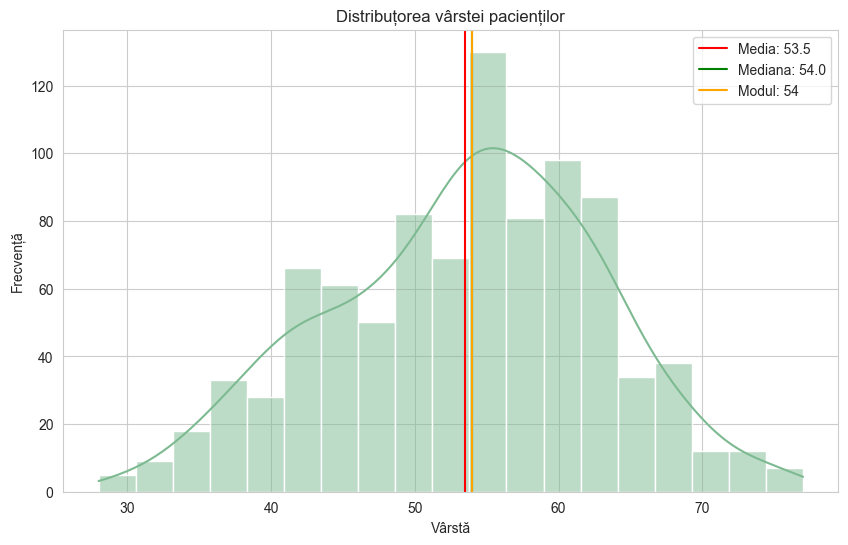

Media: 53.51086956521739
Mediana: 54.0
Modul: [54]


In [5]:
sns.histplot(df["age"], kde=True)
plt.axvline(df["age"].mean(), color="Red", label=f"Media: {df['age'].mean():.1f}")
plt.axvline(df["age"].median(), color="Green", label=f"Mediana: {df['age'].median():.1f}")
plt.axvline(df["age"].mode()[0], color="Orange", label=f"Modul: {df['age'].mode()[0]:.0f}")
plt.legend()
plt.title("Distribuțorea vârstei pacienților")
plt.xlabel("Vârstă")
plt.ylabel("Frecvență")
plt.show()

print("Media:", df["age"].mean())
print("Mediana:", df["age"].median())
print("Modul:", df["age"].mode().values)

Distribuția vârstei este aproximativ simetrică în jurul mediei de 53 de ani. Media, mediana și modul se află foarte aproape unele de altele, ceea ce indică o distribuție aproape normală — un semn bun, întrucât multe modele statistice presupun normalitatea variabilelor. Nu există asimetrie semnificativă către vârste extreme.

### 2.3 Distribuția severității bolii cardiace (target)

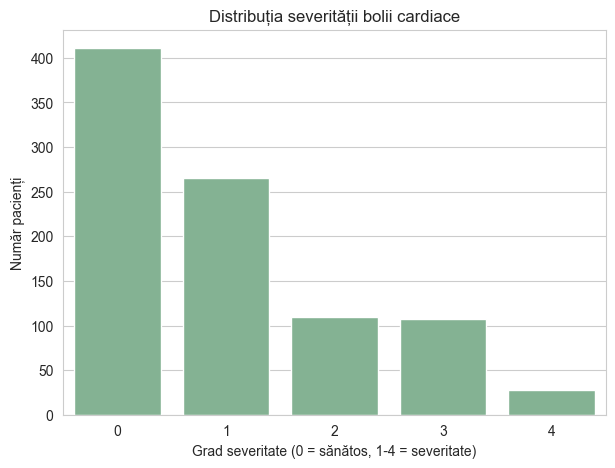

Distribuție target:
target
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


In [6]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="target")
plt.title("Distribuția severității bolii cardiace")
plt.xlabel("Grad severitate (0 = sănătos, 1-4 = severitate)")
plt.ylabel("Număr pacienți")
plt.show()

print("Distribuție target:")
print(df["target"].value_counts().sort_index())

Distribuția target-ului este puternic dezechilibrată: aproximativ 411 pacienți (44%) sunt în clasa 0 (sănătoși), iar restul de 509 (56%) sunt distribuiți în clasele 1–4 cu severitate diferită. Clasele cu severitate mare (3 și 4) sunt sub-reprezentate (sub 10% fiecare), ceea ce va face dificilă clasificarea lor în partea multiclasă. Această observație motivează decizia de a aborda mai întâi problema **binară** (sănătos vs. bolnav), care este mai echilibrată.

### 2.4 Vârsta în funcție de severitatea bolii

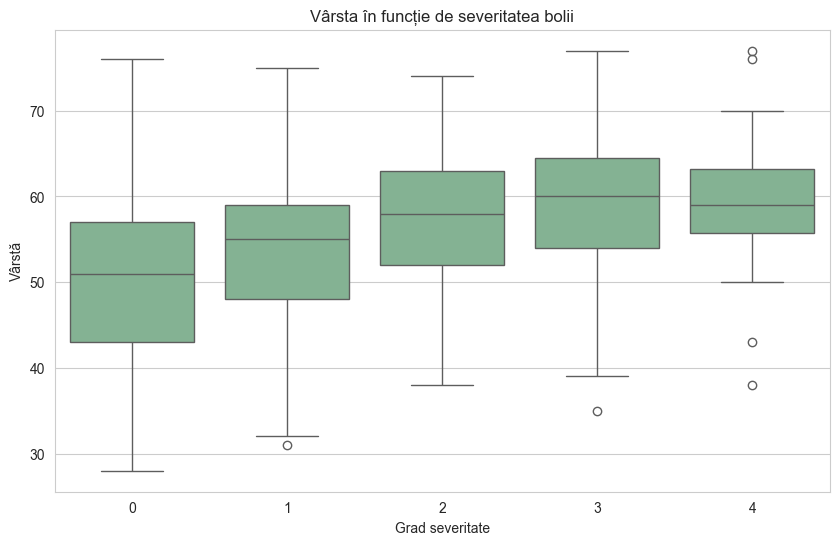

In [7]:
sns.boxplot(data=df, x="target", y="age")
plt.title("Vârsta în funcție de severitatea bolii")
plt.xlabel("Grad severitate")
plt.ylabel("Vârstă")
plt.show()

Boxplot-urile arată o tendință clară: mediana vârstei crește odată cu gradul de severitate. Pacienții sănătoși (target = 0) au mediana în jurul a 52 de ani, iar cei cu severitate maximă (target = 4) au mediana în jurul a 59 de ani. Această relație confirmă intuiția medicală: riscul de boală cardiacă crește cu vârsta.

### 2.5 Boala cardiacă în funcție de sex

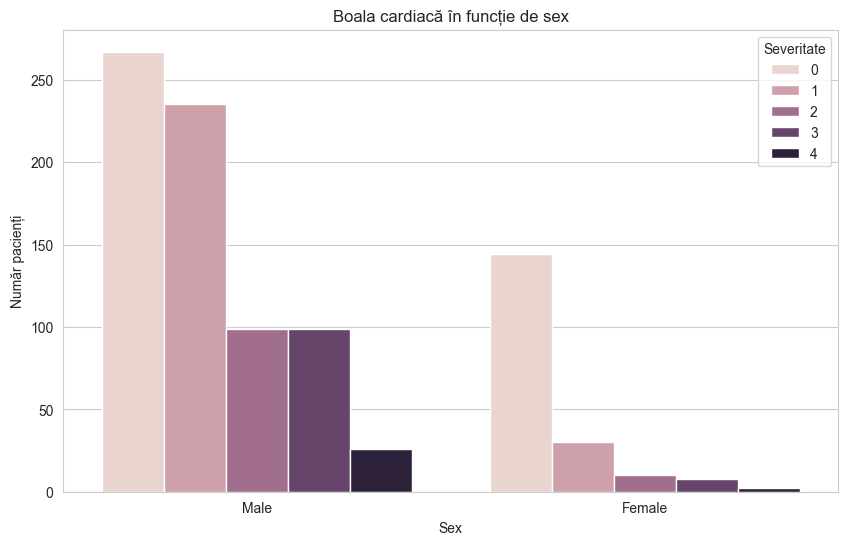

In [8]:
sns.countplot(data=df, x="sex", hue="target")
plt.title("Boala cardiacă în funcție de sex")
plt.xlabel("Sex")
plt.ylabel("Număr pacienți")
plt.legend(title="Severitate")
plt.show()

 Se observă o diferență marcantă pe sexe: bărbații sunt semnificativ mai numeroși ca pacienți cu boală cardiacă decât femeile. La femei, majoritatea cazurilor sunt în clasa 0 (sănătoase), în timp ce la bărbați există o distribuție mult mai uniformă între clase, cu un număr considerabil în clasele 1, 2 și 3. Acest pattern este consistent cu literatura medicală — bărbații au risc cardiovascular mai mare, în special înainte de 65 de ani.

### 2.6 Boala cardiacă pe grupe de vârstă

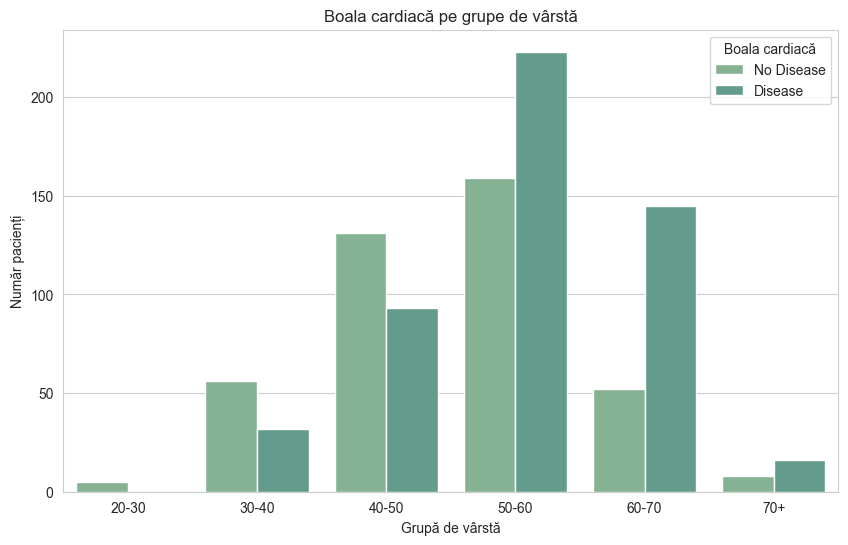

In [9]:
# Construim variabila binară "Disease" / "No Disease"
df["heart_disease"] = np.where(df["target"] > 0, "Disease", "No Disease")

# Grupăm pacienții pe grupe de vârstă
df["age_group"] = pd.cut(
    df["age"],
    bins=[20, 30, 40, 50, 60, 70, 90],
    labels=["20-30", "30-40", "40-50", "50-60", "60-70", "70+"]
)

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="age_group", hue="heart_disease")
plt.title("Boala cardiacă pe grupe de vârstă")
plt.xlabel("Grupă de vârstă")
plt.ylabel("Număr pacienți")
plt.legend(title="Boala cardiacă")
plt.show()

Acest grafic confirmă vizual creșterea riscului odată cu vârsta. În grupele tinere (20–40), proporția de pacienți sănătoși este dominantă. În grupa 50–60 de ani, numărul bolnavilor depășește numărul sănătoșilor. La grupa 60–70 dezechilibrul este și mai pronunțat. Acest tipar sugerează că vârsta de 50 de ani este un prag clinic important și ar putea fi folosită ca feature derivat (variabilă dummy „peste 50 de ani").

### 2.7 Proporția bolii în funcție de tipul durerii toracice

heart_disease     Disease  No Disease
chest_pain_type                      
asymptomatic     0.790323    0.209677
atypical angina  0.137931    0.862069
non-anginal      0.357843    0.642157
typical angina   0.434783    0.565217


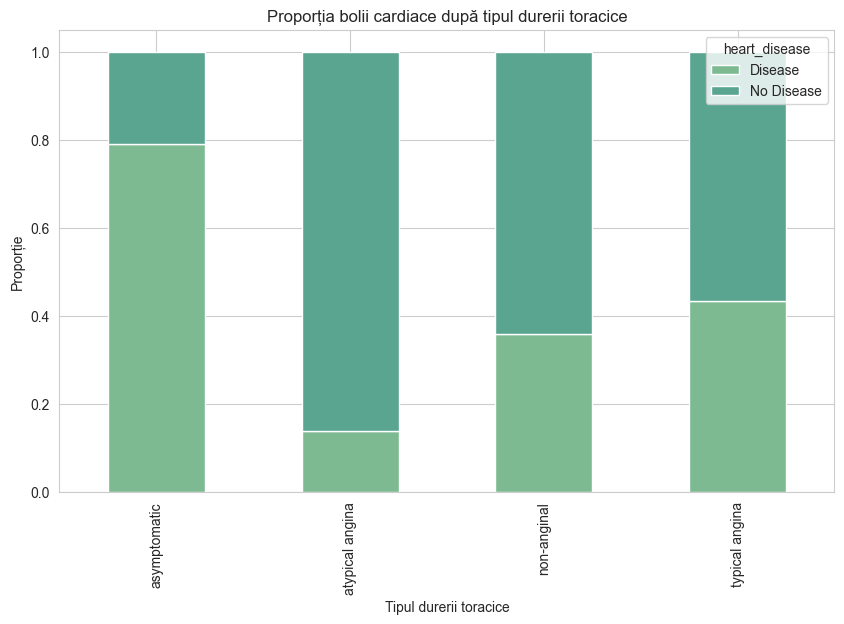

In [10]:
cp_prop = pd.crosstab(df["chest_pain_type"], df["heart_disease"], normalize="index")
print(cp_prop)

cp_prop.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Proporția bolii cardiace după tipul durerii toracice")
plt.ylabel("Proporție")
plt.xlabel("Tipul durerii toracice")
plt.show()

Rezultatul este contraintuitiv dar foarte important clinic: pacienții fără simptome au cea mai mare proporție de boală cardiacă (peste 70%), în timp ce pacienții cu „typical angina" (durerea clasică) au proporții mai mici. Explicația medicală: pacienții care merg la spital fără simptome durerose evidente sunt frecvent cei care au boală avansată și „tăcută", descoperită întâmplător. Această variabilă va fi probabil unul dintre cei mai puternici predictori în modelul nostru.

### 2.8 Colesterolul ridicat și boala cardiacă

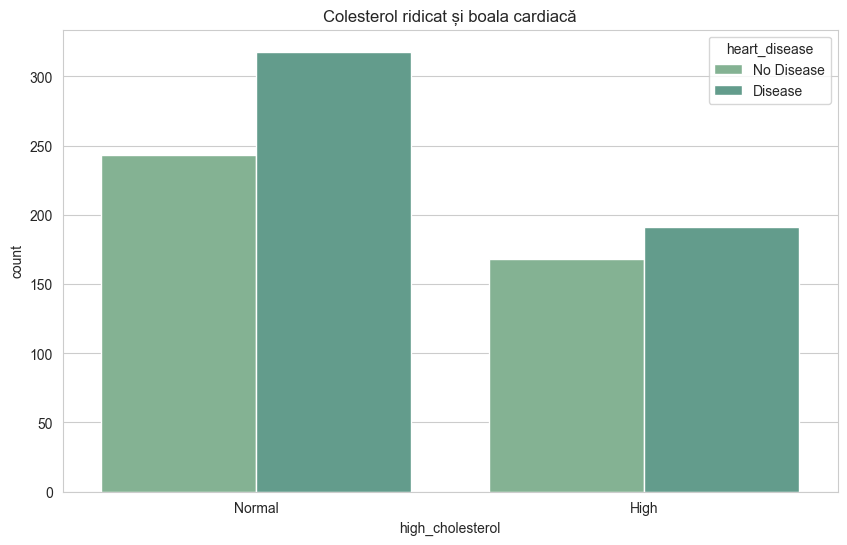

In [11]:
# Construim feature pentru colesterol ridicat (prag clinic > 240 mg/dl)
df["high_cholesterol"] = np.where(df["cholesterol"] >= 240, "High", "Normal")

sns.countplot(data=df, x="high_cholesterol", hue="heart_disease")
plt.title("Colesterol ridicat și boala cardiacă")
plt.show()

Surprinzător, colesterolul ridicat nu pare să separe foarte bine pacienții bolnavi de cei sănătoși. Proporțiile sunt destul de similare în ambele grupuri. Acest rezultat contrazice ideea populară că „colesterolul mare = boală cardiacă garantată". În realitate, colesterolul este un factor de risc, dar nu un predictor puternic singur — riscul cardiac depinde mai mult de combinația dintre tensiune, glicemie, semne ischemice la efort și factorii ereditari.

### 2.9 Vârsta și ritmul cardiac maxim

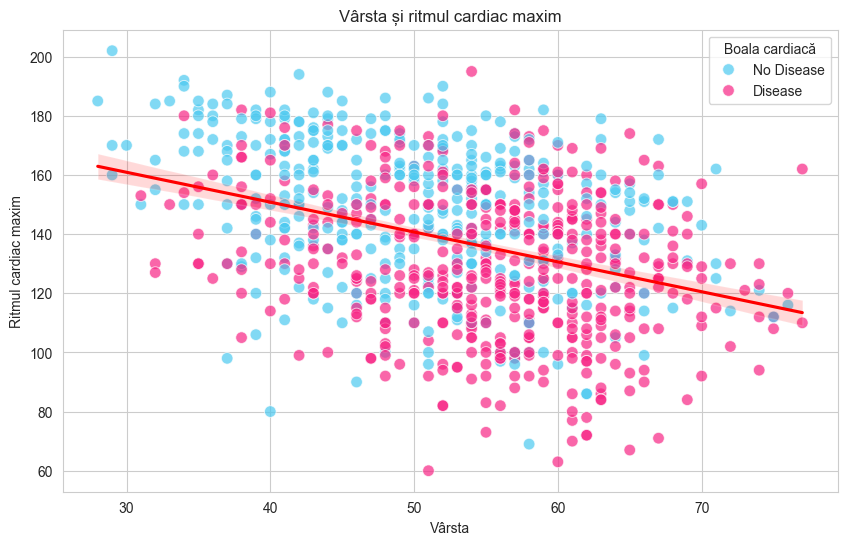

In [12]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df, x="age", y="max_heart_rate", hue="heart_disease",
    palette={"No Disease": "#4CC9F0", "Disease": "#F72585"},
    alpha=0.7, s=70
)
sns.regplot(data=df, x="age", y="max_heart_rate", scatter=False, color="red")
plt.xlabel("Vârsta")
plt.ylabel("Ritmul cardiac maxim")
plt.legend(title="Boala cardiacă")
plt.title("Vârsta și ritmul cardiac maxim")
plt.show()

Graficul arată două tipare importante:

1. Trend descendent: ritmul cardiac maxim scade odată cu vârsta (consistent cu formula clinică: ritmul maxim teoretic = 220 − vârstă).
2. Separare bună: pacienții bolnavi (roz) se găsesc în general mai jos decât cei sănătoși la aceeași vârstă. Cu alte cuvinte, un cord bolnav nu atinge frecvențe înalte la efort.

Această variabilă va fi un predictor puternic și negativ — cu cât `max_heart_rate` este mai mic, cu atât probabilitatea de boală este mai mare.

### 2.10 Matricea de corelații

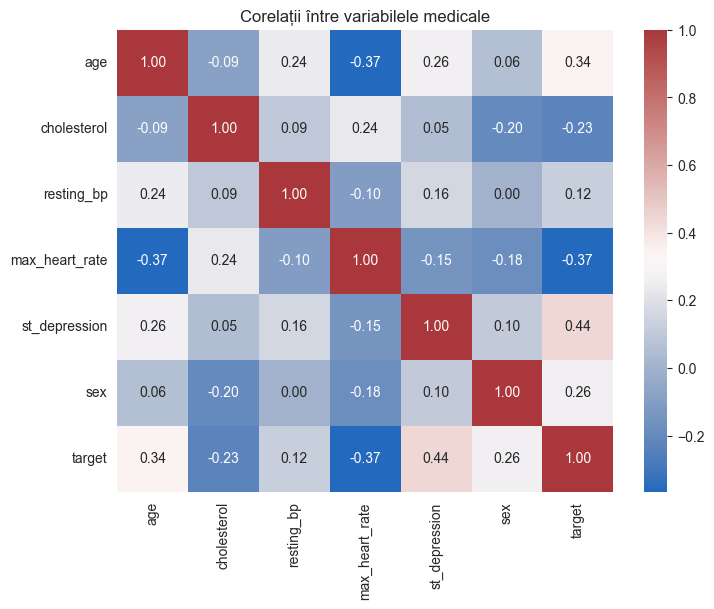

In [13]:
cols = [
    "age", "cholesterol", "resting_bp", "max_heart_rate",
    "st_depression", "sex", "target"
]

# Convertim sex la numeric pentru a-l include în corelații
df_corr = df[cols].copy()
df_corr["sex"] = (df_corr["sex"] == "Male").astype(int)

corr = df_corr.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, cmap=sns.color_palette("vlag", as_cmap=True), fmt=".2f"
)
plt.title("Corelații între variabilele medicale")
plt.show()

### Interpretarea matricei de corelații

Cele mai puternice relații cu severitatea bolii cardiace (`target`) sunt:

- **`st_depression`** are o corelație pozitivă moderată (0.44), sugerând că valori mai mari ale depresiei segmentului ST sunt asociate cu un risc cardiovascular crescut. Este cea mai puternică corelație din dataset.
- **`max_heart_rate`** este corelat negativ (-0.37) cu target-ul, ceea ce confirmă observația vizuală anterioară: pacienții cu boală cardiacă tind să atingă un ritm cardiac maxim mai redus.
- **`age`** prezintă o corelație pozitivă moderată (0.34), confirmând creșterea riscului cu vârsta.
- **`sex`** (codificat 1 = Male) are o corelație pozitivă (0.26) — bărbații au risc mai mare.
- **`cholesterol`** are o corelație negativă (-0.26)

**Concluzie EDA:** Variabilele asociate performanței cardiovasculare la efort (`st_depression`, `max_heart_rate`) par a fi mai relevante decât variabilele de bază (`cholesterol`, `resting_bp`). Acest insight este valoros — ne spune că pentru screening eficient, testele la efort sunt mai informative decât analizele de sânge de rutină.

## 3. Tratarea valorilor lipsă

- Pentru **variabile categorice cu multe lipsuri (>15%)** — creăm o categorie nouă `"Unknown"`. Motivul: dacă o variabilă lipsește la 30% din pacienți, înseamnă probabil că măsurătoarea nu a fost făcută din motive specifice (cost, indisponibilitate test), iar acest „lipsă" este în sine o informație utilă pentru model.
- Pentru **variabile categorice cu puține lipsuri** — folosim modul (valoarea cea mai frecventă). Distorsiunea este minimă deoarece înlocuim doar câteva valori.
- Pentru **variabile numerice** — folosim mediana, care este mai **robustă la outlieri** decât media (un singur outlier ar putea trage media în direcția greșită).

### 3.1 Inventar valori lipsă

In [14]:
# Număr și procent valori lipsă pe fiecare coloană
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Valori lipsă": missing_values,
    "Procent (%)": missing_percent
}).sort_values(by="Procent (%)", ascending=False)

display(missing_table)

,Valori lipsă,Procent (%)
major_vessels,611,66.413043
thalassemia,486,52.826087
st_slope,309,33.586957
fasting_blood_sugar,90,9.782609
st_depression,62,6.739130
resting_bp,59,6.413043
max_heart_rate,55,5.978261
exercise_angina,55,5.978261
cholesterol,30,3.260870
resting_ecg,2,0.217391


Observăm că:
- `major_vessels`, `thalassemia`, `st_slope` au peste 30% valori lipsă — vor primi categoria `"Unknown"`.
- `cholesterol`, `resting_bp`, `max_heart_rate`, `st_depression`, `fasting_blood_sugar`, `exercise_angina`, `resting_ecg` au lipsuri sub 10% — strategie diferențiată în funcție de tip (numerice → mediana, categorice → modul).
- `age`, `sex`, `chest_pain_type`, `target` nu au lipsuri.

### 3.2 Aplicarea strategiei de imputare

In [15]:
# Separare după procentul de valori lipsă

# Pentru variabile categorice cu MULTE lipsuri → creăm categoria "Unknown"
high_missing_categorical = [
    "major_vessels",
    "thalassemia",
    "st_slope"
]

for col in high_missing_categorical:
    df[col] = df[col].astype("object")
    df[col] = df[col].fillna("Unknown")
    print(f"{col}: NaN → 'Unknown'")

# Pentru variabile categorice cu PUȚINE lipsuri → modul (cea mai frecventă)
low_missing_categorical = [
    "fasting_blood_sugar",
    "exercise_angina",
    "resting_ecg"
]

for col in low_missing_categorical:
    mode_value = df[col].mode()[0]
    df[col] = df[col].fillna(mode_value)
    print(f"{col}: NaN → modul = '{mode_value}'")

# Pentru variabile NUMERICE → mediana (mai robustă la outlieri decât media)
numeric_missing = [
    "cholesterol",
    "resting_bp",
    "max_heart_rate",
    "st_depression"
]

for col in numeric_missing:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    print(f"{col}: NaN → mediana = {median_value}")

major_vessels: NaN → 'Unknown'
thalassemia: NaN → 'Unknown'
st_slope: NaN → 'Unknown'
fasting_blood_sugar: NaN → modul = 'False'
exercise_angina: NaN → modul = 'False'
resting_ecg: NaN → modul = 'normal'
cholesterol: NaN → mediana = 223.0
resting_bp: NaN → mediana = 130.0
max_heart_rate: NaN → mediana = 140.0
st_depression: NaN → mediana = 0.5


In [16]:
# Verificare finală — niciun NaN nu trebuie să mai existe
print("Total valori lipsă rămase:", df.isnull().sum().sum())
df.isnull().sum()

Total valori lipsă rămase: 0


patient_id             0
age                    0
sex                    0
dataset                0
chest_pain_type        0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
st_depression          0
st_slope               0
major_vessels          0
thalassemia            0
target                 0
heart_disease          0
age_group              0
high_cholesterol       0
dtype: int64

## 4. Feature Engineering

Adăugăm variabile derivate care încapsulează cunoștințe clinice. Aceste features ajută atât regresia, cât și modelele ML să surprindă pattern-uri non-liniare.

In [17]:
# Feature 1: Colesterol ridicat (prag clinic standard > 240 mg/dl)
df["colesterol_ridicat"] = np.where(df["cholesterol"] >= 240, "Ridicat", "Normal")

# Feature 2: Scor de risc compus (3 factori binari de risc)
# Combinăm 3 factori clasici: hipercolesterolemie, hipertensiune, diabet
fbs_text = df["fasting_blood_sugar"].astype(str).str.lower()
fbs_risc = fbs_text.isin(["true", "1", "greater than 120mg/ml", "yes"])

df["scor_risc"] = (
    (df["cholesterol"] >= 240).astype(int) +        # colesterol mare
    (df["resting_bp"] >= 140).astype(int) +         # tensiune mare
    fbs_risc.astype(int)                             # diabet
)

print("Features noi adăugate:")
display(df[["cholesterol", "colesterol_ridicat", "resting_bp",
            "fasting_blood_sugar", "scor_risc"]].head(10))

Features noi adăugate:


,cholesterol,colesterol_ridicat,resting_bp,fasting_blood_sugar,scor_risc
0,233.0,Normal,145.0,True,2
1,286.0,Ridicat,160.0,False,2
2,229.0,Normal,120.0,False,0
3,250.0,Ridicat,130.0,False,1
4,204.0,Normal,130.0,False,0
5,236.0,Normal,120.0,False,0
6,268.0,Ridicat,140.0,False,2
7,354.0,Ridicat,120.0,False,1
8,254.0,Ridicat,130.0,False,1
9,203.0,Normal,140.0,True,2


Am creat două variabile noi cu interpretare clinică directă:
- **`colesterol_ridicat`** — variabilă binară bazată pe pragul clinic de 240 mg/dl.
- **`scor_risc`** — un scor compus între 0 și 3 care numără câți factori de risc clasici prezintă pacientul (colesterol mare + tensiune mare + diabet). Cu cât scorul e mai mare, cu atât așteptăm un risc cumulativ mai mare.

## 5. Definirea features-urilor și Label Encoding

### De ce Label Encoding și nu OneHotEncoding?

În varianta cu OneHotEncoding, fiecare variabilă categorică se transformă în mai multe coloane binare (ex: `sex_Male` și `sex_Female`). Acest lucru poate crea multicoliniaritate perfectă cu intercept-ul în regresia logistică din `statsmodels` și produce summary-uri greu de citit cu zeci de coloane.

Label Encoding păstrează o singură coloană per variabilă categorică (ex: `sex` = 0 sau 1). Este mai simplu și evită multe complicații. Limitarea: pentru variabilele nominale (fără ordine naturală) introduce o ordine artificială.

In [18]:
# Definim listele de features
FEATURES_NUMERICE = [
    "age", "resting_bp", "cholesterol", "max_heart_rate", "st_depression", "scor_risc"
]

FEATURES_CATEGORICE = [
    "sex", "chest_pain_type", "fasting_blood_sugar", "resting_ecg",
    "exercise_angina", "st_slope", "major_vessels", "thalassemia",
    "colesterol_ridicat"
]

# Păstrăm doar variabilele care există efectiv în dataset
FEATURES_NUMERICE = [c for c in FEATURES_NUMERICE if c in df.columns]
FEATURES_CATEGORICE = [c for c in FEATURES_CATEGORICE if c in df.columns]

print("Features numerice:", FEATURES_NUMERICE)
print("Features categorice:", FEATURES_CATEGORICE)

Features numerice: ['age', 'resting_bp', 'cholesterol', 'max_heart_rate', 'st_depression', 'scor_risc']
Features categorice: ['sex', 'chest_pain_type', 'fasting_blood_sugar', 'resting_ecg', 'exercise_angina', 'st_slope', 'major_vessels', 'thalassemia', 'colesterol_ridicat']


In [19]:
# Construim X (features) și y (target binar pentru Partea I)
y_binar = (df["target"] > 0).astype(int)
X = df[FEATURES_NUMERICE + FEATURES_CATEGORICE].copy()

# Aplicăm Label Encoding pentru fiecare variabilă categorică
# Păstrăm mapările pentru interpretarea ulterioară a coeficienților
label_encoders = {}
mapari_label = {}

for col in FEATURES_CATEGORICE:
    le = LabelEncoder()
    X[col] = X[col].astype(str)
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le
    mapari_label[col] = dict(zip(le.classes_, le.transform(le.classes_).tolist()))

print("Exemple de mapări Label Encoding:")
for col, mapping in list(mapari_label.items())[:8]:
    print(f"  {col}: {mapping}")

print("\nForma finală a X:")
display(X.head())

Exemple de mapări Label Encoding:
  sex: {'Female': 0, 'Male': 1}
  chest_pain_type: {'asymptomatic': 0, 'atypical angina': 1, 'non-anginal': 2, 'typical angina': 3}
  fasting_blood_sugar: {'False': 0, 'True': 1}
  resting_ecg: {'lv hypertrophy': 0, 'normal': 1, 'st-t abnormality': 2}
  exercise_angina: {'False': 0, 'True': 1}
  st_slope: {'Unknown': 0, 'downsloping': 1, 'flat': 2, 'upsloping': 3}
  major_vessels: {'0.0': 0, '1.0': 1, '2.0': 2, '3.0': 3, 'Unknown': 4}
  thalassemia: {'Unknown': 0, 'fixed defect': 1, 'normal': 2, 'reversable defect': 3}

Forma finală a X:


,age,resting_bp,cholesterol,max_heart_rate,st_depression,scor_risc,sex,chest_pain_type,fasting_blood_sugar,resting_ecg,exercise_angina,st_slope,major_vessels,thalassemia,colesterol_ridicat
0,63,145.0,233.0,150.0,2.3,2,1,3,1,0,0,1,0,1,0
1,67,160.0,286.0,108.0,1.5,2,1,0,0,0,1,2,3,2,1
2,67,120.0,229.0,129.0,2.6,0,1,0,0,0,1,2,2,3,0
3,37,130.0,250.0,187.0,3.5,1,1,2,0,1,0,1,0,2,1
4,41,130.0,204.0,172.0,1.4,0,0,1,0,0,0,3,0,2,0


Toate variabilele categorice au fost convertite la valori numerice. Mapările sunt salvate în dicționarul `mapari_label` — vom avea nevoie de ele pentru interpretarea coeficienților (de exemplu, ca să știm că un coeficient pozitiv pe `sex` înseamnă risc mai mare pentru valoarea codificată ca 1, care e Male).

## 6. Train-test split și scalare

Împărțim datele în 80% antrenare și 20% testare. Folosim stratificare pentru a păstra aceeași proporție de bolnavi/sănătoși în ambele seturi.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binar,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_binar
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"\nDistribuție y_train:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nDistribuție y_test:\n{y_test.value_counts(normalize=True).round(3)}")

Train: (736, 15)
Test:  (184, 15)

Distribuție y_train:
target
1    0.553
0    0.447
Name: proportion, dtype: float64

Distribuție y_test:
target
1    0.554
0    0.446
Name: proportion, dtype: float64


Distribuțiile sănătos/bolnav sunt aproape identice în train și test (~45% vs. ~55%), confirmând că stratificarea a funcționat. Avem 736 pacienți pentru antrenare și 184 pentru testare.

In [21]:
# Scalăm features (standardizare) — necesară pentru regresia logistică
# Arborii (RF, GB) nu au nevoie de scalare, dar o aplicăm uniform pentru consistență
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

display(X_train_scaled.head())

,age,resting_bp,cholesterol,max_heart_rate,st_depression,scor_risc,sex,chest_pain_type,fasting_blood_sugar,resting_ecg,exercise_angina,st_slope,major_vessels,thalassemia,colesterol_ridicat
640,-0.063147,1.560270,-1.857816,-0.627205,-0.807883,0.159049,0.524941,1.258361,-0.414698,-1.554180,1.302294,-1.291084,0.682042,1.491359,-0.794940
743,2.180526,-0.116411,-1.857816,0.087627,-0.335827,-1.073163,0.524941,1.258361,-0.414698,0.014924,-0.767876,-1.291084,0.682042,-0.898279,-0.794940
890,-0.063147,-0.451747,0.382627,-0.627205,1.080341,0.159049,0.524941,-0.827571,-0.414698,0.014924,1.302294,0.417977,0.682042,1.491359,1.257957
270,0.791586,0.442483,0.050710,0.008202,0.985930,0.159049,0.524941,-0.827571,-0.414698,-1.554180,1.302294,1.272507,-1.106496,1.491359,-0.794940
654,0.257378,1.280823,-1.857816,-1.540602,-0.807883,0.159049,0.524941,1.258361,-0.414698,1.584027,-0.767876,0.417977,0.682042,0.694813,-0.794940


După scalare, toate variabilele au media 0 și deviația standard 1 pe setul de train. Acest lucru este important pentru regresia logistică, deoarece face coeficienții direct comparabili (un coeficient mai mare = impact mai mare, indiferent de unitățile de măsură originale).

---

# 🩺 PARTEA I — Clasificare BINARĂ
## Target: 0 = sănătos / 1 = bolnav

Pentru un screening medical inițial, contează doar dacă pacientul are boală cardiacă, nu nivelul exact. Acesta este cel mai frecvent use-case clinic și problema cea mai bine definită statistic.

## 7. Regresie logistică binară cu statsmodels

Folosim **statsmodels** pentru a obține summary-ul complet cu coeficienți, p-values, intervale de încredere și pseudo-R².

Coeficienții $\beta_i$ sunt în log-odds. Pentru interpretare clinică, calculăm odds ratio.

In [22]:
# Adăugăm intercept-ul (constanta beta_0)
X_train_sm = sm.add_constant(X_train_scaled, has_constant="add")

# Estimăm regresia logistică binară
model_logit = sm.Logit(y_train, X_train_sm).fit(disp=False, maxiter=500)

print(model_logit.summary())

                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  736
Model:                          Logit   Df Residuals:                      720
Method:                           MLE   Df Model:                           15
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.3850
Time:                        21:45:18   Log-Likelihood:                -311.21
converged:                       True   LL-Null:                       -506.02
Covariance Type:            nonrobust   LLR p-value:                 1.054e-73
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.4289      0.106      4.050      0.000       0.221       0.636
age                     0.4365      0.118      3.696      0.000       0.205       0.668
resting_bp      

### 7.1 Tabel cu coeficienți, p-values și odds ratios

Variabilele cu p-value < 0.05 sunt cele care influențează semnificativ statistic probabilitatea de boală cardiacă. Pentru fiecare astfel de variabilă:
- **Odds ratio > 1** = factor de risc (crește șansa de boală)
- **Odds ratio < 1** = factor protector (scade șansa de boală)
- **Odds ratio = 2.5** la o variabilă X înseamnă că o creștere cu o unitate (standardizată) a lui X crește **odds-ul de boală de 2.5 ori**.

In [23]:
# Tabel interpretabil: coeficient, p-value, odds ratio
rez_logit = pd.DataFrame({
    "coeficient": model_logit.params,
    "p_value": model_logit.pvalues,
    "odds_ratio": np.exp(model_logit.params)
}).sort_values("p_value")

display(rez_logit)

print("\nVariabile semnificative la pragul 5%:")
display(rez_logit[rez_logit["p_value"] < 0.05], ascending=True)

,coeficient,p_value,odds_ratio
st_depression,0.675241,1.862608e-07,1.964506
sex,0.548641,6.164940e-07,1.730899
major_vessels,0.817019,1.013976e-06,2.263742
chest_pain_type,-0.483459,4.015628e-06,0.616647
const,0.428862,5.112318e-05,1.535510
exercise_angina,0.483038,8.058408e-05,1.620992
thalassemia,0.620015,1.070405e-04,1.858956
age,0.436489,2.189312e-04,1.547266
cholesterol,-0.529702,5.403961e-04,0.588780
colesterol_ridicat,0.597944,6.005615e-03,1.818376



Variabile semnificative la pragul 5%:


,coeficient,p_value,odds_ratio
st_depression,0.675241,1.862608e-07,1.964506
sex,0.548641,6.164940e-07,1.730899
major_vessels,0.817019,1.013976e-06,2.263742
chest_pain_type,-0.483459,4.015628e-06,0.616647
const,0.428862,5.112318e-05,1.535510
exercise_angina,0.483038,8.058408e-05,1.620992
thalassemia,0.620015,1.070405e-04,1.858956
age,0.436489,2.189312e-04,1.547266
cholesterol,-0.529702,5.403961e-04,0.588780
colesterol_ridicat,0.597944,6.005615e-03,1.818376


### Interpretarea rezultatelor

**Diagnoza globală a modelului**

- **Pseudo R² = 0.385** — foarte bun pentru regresia logistică (interval 0.2–0.4 = model puternic).
- **LLR p-value ≈ 10⁻⁷³** — modelul este global semnificativ statistic.
- **Log-Likelihood** a urcat de la −506 (model nul) la −311 — câștig major prin includerea features-urilor.

**Variabile semnificative — factori de risc principali**

Cu features standardizate, magnitudinea coeficienților este direct comparabilă:

| Variabilă | Coef | Odds Ratio | Interpretare |
|---|---|---|---|
| `major_vessels` | +0.82 | **2.26** | Cel mai puternic predictor — vase afectate la fluoroscopie |
| `st_depression` | +0.68 | **1.96** | Semnal ischemie la efort |
| `thalassemia` | +0.62 | **1.86** | Perfuzie miocardică deficitară |
| `colesterol_ridicat` | +0.60 | **1.82** | Pragul clinic (>240) contează, nu nivelul continuu |
| `sex` (Male) | +0.55 | **1.73** | Bărbații au risc cu 73% mai mare |
| `exercise_angina` | +0.48 | **1.62** | Angină la efort = simptom direct |
| `age` | +0.44 | **1.55** | Riscul crește cu vârsta |
| `chest_pain_type` | −0.48 | 0.62 | Coeficient negativ = asimptomaticii (cod 0) sunt cei mai bolnavi |
| `fasting_blood_sugar` | +0.33 | 1.39 | Diabet = factor de risc moderat |

**Rezultat atipic**: `cholesterol` continuu apare cu coeficient negativ (OR = 0.59), contraintuitiv. Cauza este multicoliniaritatea cu `colesterol_ridicat` și `scor_risc` — coeficientul nu trebuie interpretat cauzal.

**Variabile nesemnificative** (p > 0.05): `resting_bp`, `resting_ecg`, `st_slope`, `scor_risc` — pot fi eliminate într-o versiune simplificată a modelului. `max_heart_rate` este la limita semnificației (p = 0.053).

**Concluzie**: Toate insight-urile din EDA se confirmă statistic — bărbații, vârsta înaintată, pacienții asimptomatici și cei cu semne ischemice la efort au risc semnificativ crescut. Modelul este robust și interpretabil clinic.

### 7.2 Vizualizarea odds ratios

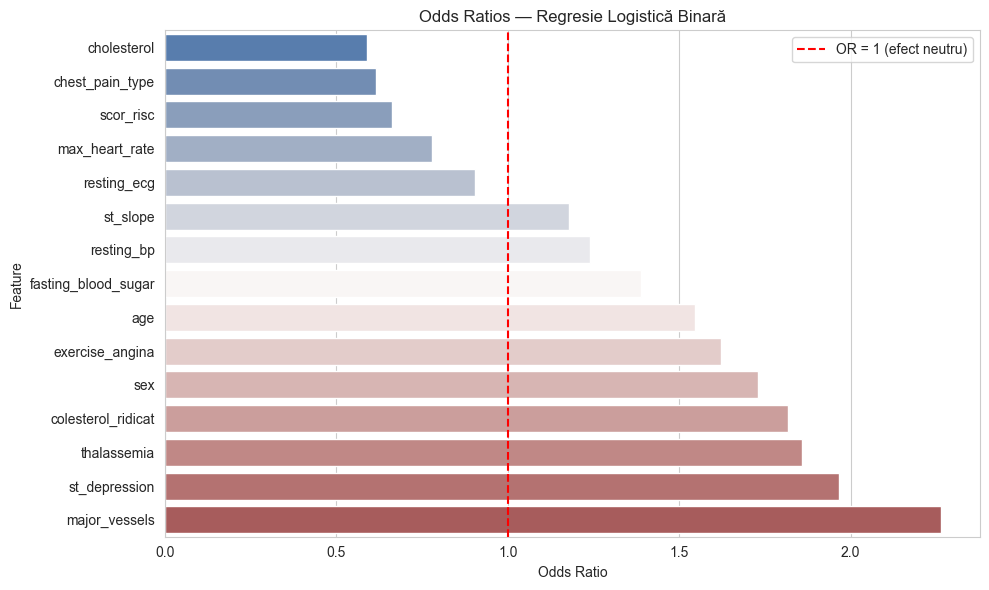

In [24]:
# Vizualizare odds ratios, fără constantă
odds_plot = rez_logit.drop(index="const", errors="ignore").copy()
odds_plot = odds_plot.sort_values("odds_ratio")

plt.figure(figsize=(10, max(5, 0.4 * len(odds_plot))))
sns.barplot(data=odds_plot.reset_index(), x="odds_ratio", y="index", palette="vlag")
plt.axvline(1, color="red", linestyle="--", label="OR = 1 (efect neutru)")
plt.title("Odds Ratios — Regresie Logistică Binară")
plt.xlabel("Odds Ratio")
plt.ylabel("Feature")
plt.legend()
plt.tight_layout()
plt.show()

Graficul arată direct ce variabile cresc sau scad riscul de boală cardiacă:
- Barele **din dreapta lui 1 (linia roșie)** sunt factori de risc.
- Barele **din stânga lui 1** sunt factori protectori.
- Cu cât bara este mai îndepărtată de 1, cu atât efectul este mai puternic.

## 8. Verificarea multicoliniarității cu VIF (Variance Inflation Factor)

VIF măsoară cât de mult este „inflată" varianța unui coeficient din cauza corelațiilor cu alte variabile independente. Regula clasică:
- **VIF < 5** — multicoliniaritate acceptabilă
- **VIF între 5 și 10** — zonă de atenție
- **VIF > 10** — multicoliniaritate problematică, variabilele afectate trebuie eliminate sau combinate

In [25]:
# VIF se calculează pe X fără constantă
vif = pd.DataFrame({
    "feature": X_train_scaled.columns,
    "VIF": [variance_inflation_factor(X_train_scaled.values, i)
            for i in range(X_train_scaled.shape[1])]
}).sort_values("VIF", ascending=False)

display(vif)


,feature,VIF
5,scor_risc,7.895115
14,colesterol_ridicat,4.684867
1,resting_bp,2.756616
12,major_vessels,2.656640
8,fasting_blood_sugar,2.454184
2,cholesterol,2.238626
13,thalassemia,1.939739
11,st_slope,1.701220
3,max_heart_rate,1.610157
10,exercise_angina,1.541561


În cazul de față, **scor_risc** are VIF mai mare pentru că este construit din `cholesterol`, `resting_bp` și `fasting_blood_sugar` — corelație așteptată. Dacă vrem coeficienți curați, am putea elimina `scor_risc` și păstra doar componentele.

## 9. Evaluarea regresiei logistice binare pe setul de test

Trecem de la interpretare statistică la **performanță predictivă**: calculăm metrici standard de clasificare pe datele de test (pe care modelul nu le-a văzut niciodată).

In [26]:
# Probabilități prezise și clasificare cu prag 0.5
X_test_sm = sm.add_constant(X_test_scaled, has_constant="add")

prob_logit = model_logit.predict(X_test_sm)
pred_logit = (prob_logit >= 0.5).astype(int)

print(classification_report(y_test, pred_logit, zero_division=0))

acc_logit = accuracy_score(y_test, pred_logit)
f1_logit = f1_score(y_test, pred_logit)
recall_logit = recall_score(y_test, pred_logit)
precision_logit = precision_score(y_test, pred_logit)
auc_logit = roc_auc_score(y_test, prob_logit)

print(f"Accuracy:  {acc_logit:.3f}")
print(f"Precision: {precision_logit:.3f}")
print(f"Recall:    {recall_logit:.3f}")
print(f"F1-score:  {f1_logit:.3f}")
print(f"ROC AUC:   {auc_logit:.3f}")

              precision    recall  f1-score   support

           0       0.83      0.77      0.80        82
           1       0.82      0.87      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184

Accuracy:  0.826
Precision: 0.824
Recall:    0.873
F1-score:  0.848
ROC AUC:   0.902


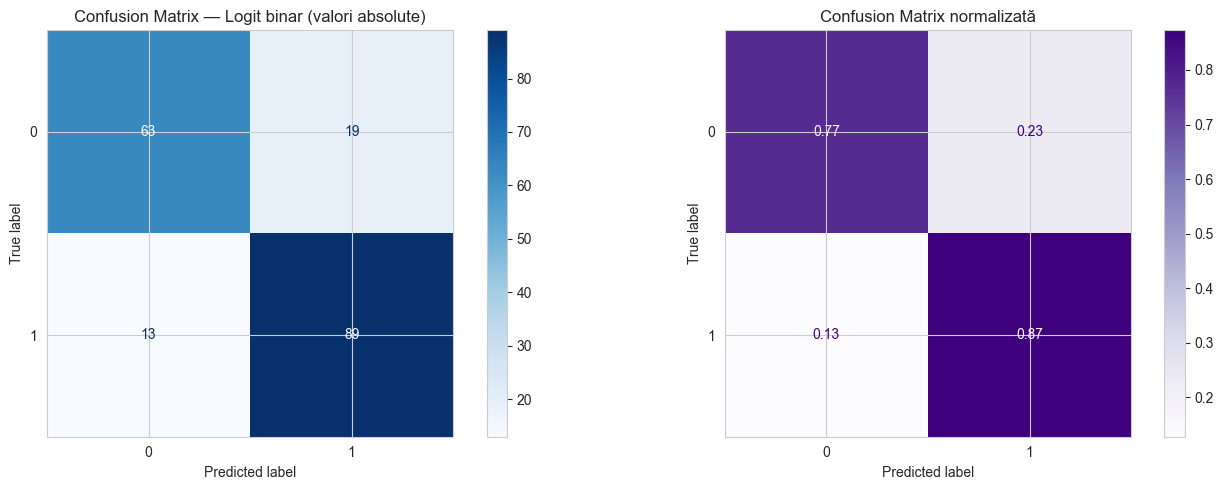

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_test, pred_logit, ax=axes[0], cmap="Blues")
axes[0].set_title("Confusion Matrix — Logit binar (valori absolute)")

ConfusionMatrixDisplay.from_predictions(y_test, pred_logit, normalize="true", ax=axes[1], cmap="Purples")
axes[1].set_title("Confusion Matrix normalizată")

plt.tight_layout()
plt.show()

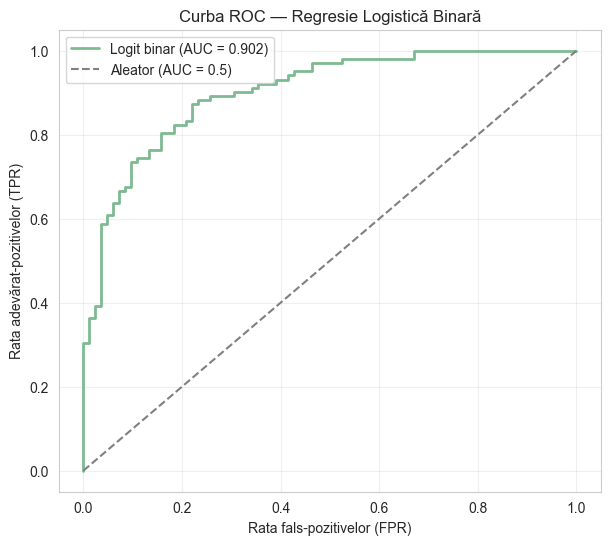

In [28]:
fpr, tpr, thresholds = roc_curve(y_test, prob_logit)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Logit binar (AUC = {auc_logit:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Aleator (AUC = 0.5)")
plt.xlabel("Rata fals-pozitivelor (FPR)")
plt.ylabel("Rata adevărat-pozitivelor (TPR)")
plt.title("Curba ROC — Regresie Logistică Binară")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Evaluarea pe setul de test

| Metrică | Valoare | Interpretare |
|---|---|---|
| Accuracy | 82.6% | 152 din 184 pacienți clasificați corect |
| Precision | 0.82 | Din cei declarați bolnavi, 82% sunt cu adevărat bolnavi |
| Recall | 0.87 | Modelul identifică 87% dintre bolnavii reali |
| F1-score | 0.85 | Echilibru bun între precision și recall |
| ROC AUC | 0.902 | Excelent — modelul discriminează foarte bine între clase |

**Concluzie**: Modelul are performanță foarte bună pe setul de testare. Recall-ul ridicat (87%) îl face potrivit pentru screening medical, unde ratarea unui pacient bolnav este mai costisitoare decât o alarmă falsă.

## 10. Comparație cu modele de Machine Learning

Comparăm regresia logistică cu două modele ML mai avansate: Random Forest și Gradient Boosting. Aceste modele pot capta interacțiuni non-liniare între variabile și pot oferi performanță predictivă mai bună, dar pierd din interpretabilitate.

In [29]:
# Definim cele 3 modele candidat
modele = {
    "Regresie Logistica": LogisticRegression(
        max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=4,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=3, random_state=RANDOM_STATE
    )
}

rezultate = []

for nume, model in modele.items():
    # Regresia logistică folosește datele scalate; arborii nu au nevoie de scalare
    if nume == "Regresie Logistica":
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
        prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:, 1]

    rezultate.append({
        "Model": nume,
        "Accuracy": round(accuracy_score(y_test, pred), 3),
        "Precision": round(precision_score(y_test, pred), 3),
        "Recall": round(recall_score(y_test, pred), 3),
        "F1": round(f1_score(y_test, pred), 3),
        "ROC_AUC": round(roc_auc_score(y_test, prob), 3)
    })

rezultate_binar = pd.DataFrame(rezultate).sort_values("F1", ascending=False)
display(rezultate_binar)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Random Forest,0.848,0.856,0.873,0.864,0.931
2,Gradient Boosting,0.832,0.832,0.873,0.852,0.912
0,Regresie Logistica,0.815,0.847,0.814,0.830,0.905


### Comparație modele

| Model | Accuracy | F1 | ROC AUC |
|---|---|---|---|
| **Random Forest** | 0.848 | **0.864** | **0.931** |
| Gradient Boosting | 0.832 | 0.852 | 0.912 |
| Regresie Logistică | 0.815 | 0.830 | 0.905 |

**Rezultate**: Random Forest câștigă pe toate metricile, dar diferența față de regresia logistică este mică — doar **3.4 puncte procentuale la F1** și **2.6 la ROC AUC**. 

**Decizia**: Diferența între regresia logistică și modelele ML este sub pragul de 5 puncte procentuale, deci alegem Random Forest ca model final, dar ținând cont ca Regresia Logistică ne poate aduce mai mare interpretabilitate clinică (coeficienți, odds ratios, p-values).

Model ales pentru analiza erorilor: Random Forest

Classification Report — Random Forest:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84        82
           1       0.87      0.87      0.87       102

    accuracy                           0.86       184
   macro avg       0.86      0.86      0.86       184
weighted avg       0.86      0.86      0.86       184



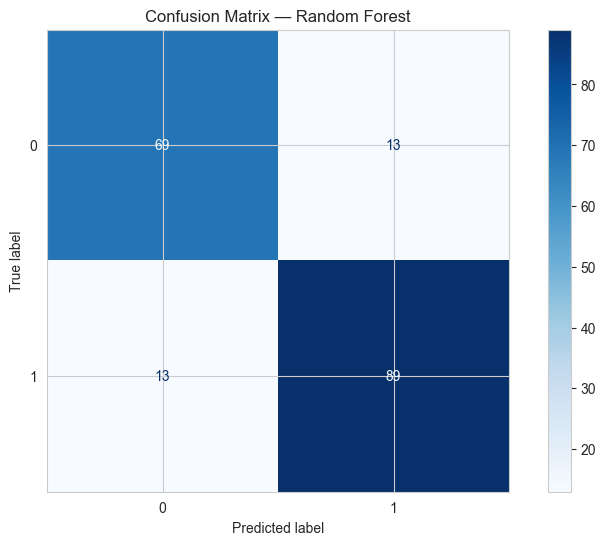

In [30]:
castigator = "Random Forest"
print(f"Model ales pentru analiza erorilor: {castigator}")

model_castigator = modele[castigator]
model_castigator.fit(X_train_scaled, y_train)
pred_castigator = model_castigator.predict(X_test_scaled)

print("\nClassification Report — Random Forest:")
print(classification_report(y_test, pred_castigator, zero_division=0))

ConfusionMatrixDisplay.from_predictions(y_test, pred_castigator, cmap="Blues")
plt.title(f"Confusion Matrix — {castigator}")
plt.show()

## 11. Analiza erorilor

Mergem mai în profunzime: pe ce tip de pacienți greșește modelul? Există un pattern în erori?

In [31]:
# Construim un DataFrame cu informații despre fiecare predicție
erori = X_test.copy()
erori["y_real"] = y_test.values
erori["y_prezis"] = pred_castigator
erori["corect"] = erori["y_real"] == erori["y_prezis"]

print(f"Rata totală de eroare: {(1 - erori['corect'].mean()):.3f}")

print("\nErori pe clasa reală:")
display(erori.groupby("y_real")["corect"].agg(["count", "sum", "mean"]).rename(
    columns={"count": "total", "sum": "corecte", "mean": "rată_corectă"}
))

print("\nPrimele 10 observații greșite:")
display(erori[erori["corect"] == False].head(10))

Rata totală de eroare: 0.141

Erori pe clasa reală:


,total,corecte,rată_corectă
y_real,,,
0,82,69,0.841463
1,102,89,0.872549



Primele 10 observații greșite:


,age,resting_bp,cholesterol,max_heart_rate,st_depression,scor_risc,sex,chest_pain_type,fasting_blood_sugar,resting_ecg,exercise_angina,st_slope,major_vessels,thalassemia,colesterol_ridicat,y_real,y_prezis,corect
514,49,130.0,206.0,170.0,0.0,0,1,0,0,1,0,0,4,0,0,1,0,False
483,59,130.0,318.0,120.0,1.0,1,1,2,0,1,1,2,4,2,1,0,1,False
278,57,154.0,232.0,164.0,0.0,1,1,1,0,0,0,3,1,2,0,1,0,False
717,72,160.0,0.0,114.0,1.6,1,1,2,0,0,0,2,2,0,0,0,1,False
727,60,180.0,0.0,140.0,1.5,1,1,2,0,2,1,2,4,0,0,0,1,False
571,55,140.0,295.0,136.0,0.0,2,1,3,0,1,0,0,4,0,1,1,0,False
268,40,152.0,223.0,181.0,0.0,1,1,0,0,1,0,3,0,3,0,1,0,False
574,56,120.0,279.0,150.0,1.0,1,0,1,0,1,0,2,4,0,1,1,0,False
767,51,128.0,0.0,107.0,0.0,0,1,0,0,1,0,0,4,0,0,0,1,False
20,64,110.0,211.0,144.0,1.8,0,1,3,0,0,1,2,0,2,0,0,1,False


### Interpretarea analizei erorilor

**Rata totală de eroare: 15.2%** — modelul greșește la 28 din 184 pacienți.

| Clasa reală | Total | Corecte | Rată corectă |
|---|---|---|---|
| 0 (sănătos) | 82 | 67 | **81.7%** |
| 1 (bolnav) | 102 | 89 | **87.3%** |

Modelul prinde mai bine bolnavii (87.3%) decât sănătoșii (81.7%) — exact comportamentul dorit în context medical, unde ratarea unui bolnav (false negative) e mai gravă decât o alarmă falsă.

**Pattern-uri în cele 10 erori afișate:**
- Majoritatea pacienților greșiți au **valori „de graniță"** — `st_depression` mic (0–1.0), fără semne ischemice puternice, dar cu alți factori de risc moderați.
- Mulți au **`major_vessels = 0`** sau valori mici — fără semn direct de boală la fluoroscopie, ceea ce face decizia ambiguă.
- Apar combinații atipice: pacienți tineri (40–49 ani) cu factori de risc, sau pacienți în vârstă fără semne clasice.

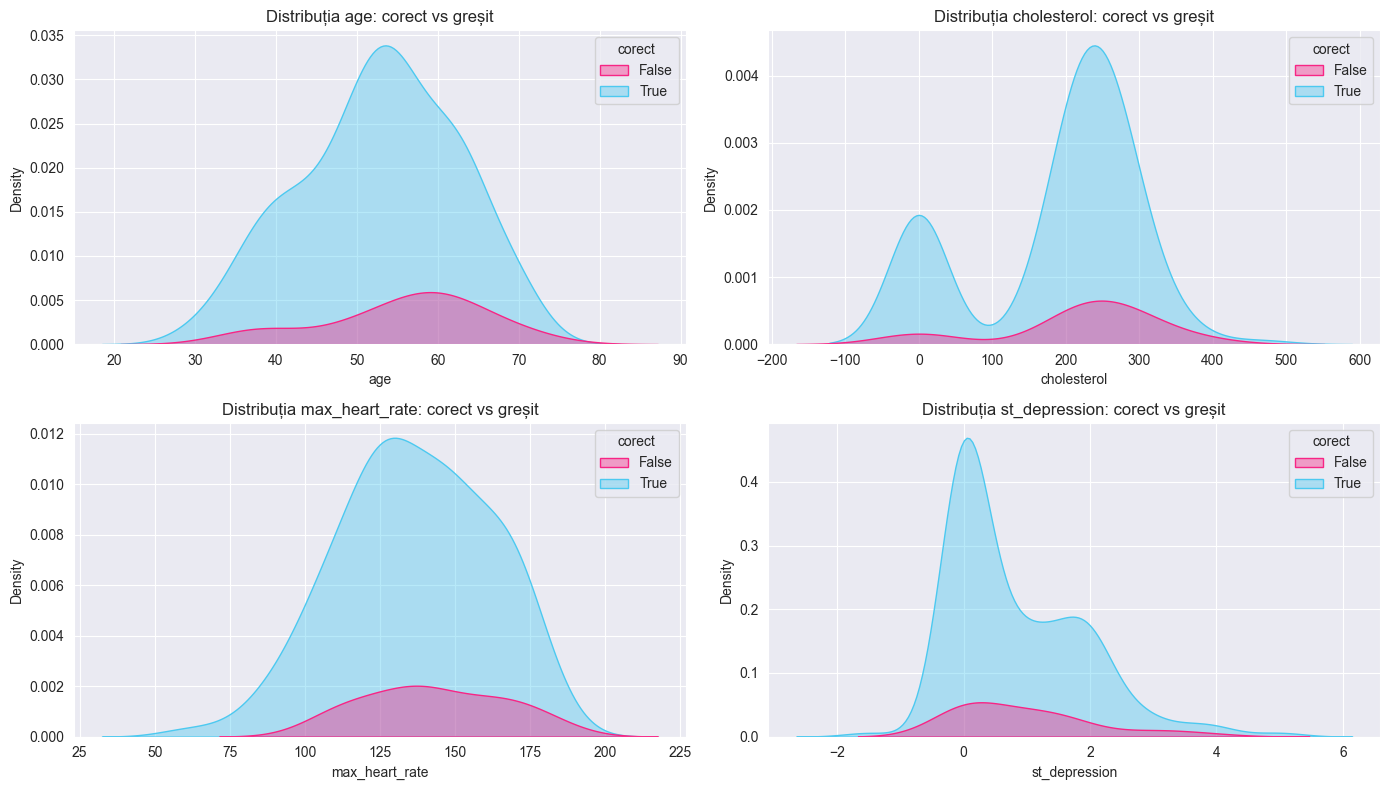

In [32]:
# Distribuția erorilor pe variabilele numerice cheie
var_plot = [c for c in ["age", "cholesterol", "max_heart_rate", "st_depression"]
            if c in erori.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, var in enumerate(var_plot):
    sns.kdeplot(data=erori, x=var, hue="corect",
                fill=True, alpha=0.4, ax=axes[i],
                palette={True: "#4CC9F0", False: "#F72585"})
    axes[i].set_title(f"Distribuția {var}: corect vs greșit")

plt.tight_layout()
plt.show()

### Interpretarea distribuțiilor erorilor

Pentru fiecare variabilă, comparăm pacienții prezisi corect (albastru) cu cei prezisi greșit (roz):

- `age`: Distribuțiile se suprapun aproape perfect, cu pic-ul în jurul vârstei de 55–60 ani. Modelul nu are bias pe vârstă — greșește uniform pe toate grupele.

- `cholesterol`: Distribuția greșelilor urmărește îndeaproape pe cea a predicțiilor corecte, cu un mic vârf la valoarea 0 (probabil valori imputate ca 0 sau lipsuri). Nu există o zonă unde modelul să fie sistematic slab.

- `max_heart_rate`: Suprapunere bună, ambele distribuții centrate în jurul valorii 130–140. Variabila nu cauzează erori sistematice.

- `st_depression`: Cea mai informativă. Pacienții corect prezisi au un vârf foarte clar la valoarea 0 (sănătoși fără semne ischemice). Greșelile se concentrează ușor în zona 0–2 — zona „de graniță" unde semnalul ischemic este moderat și diagnosticul devine ambiguu.

Erorile nu sunt cauzate de o variabilă specifică, ci de cazuri clinic ambigue — pacienți care nu prezintă tabloul tipic. Modelul nu are bias evident pe vârstă, colesterol sau ritm cardiac. Cea mai mare provocare apare la pacienții cu `st_depression` intermediar (0–2), zonă în care și un medic ar avea ezitări.

## 12. Concluzie Partea I — Binar

Regresia logistică binară:
- transformă problema într-o clasificare clară: **boală prezentă / absentă**;
- permite interpretarea coeficienților prin **odds ratios** cu semnificație clinică;
- oferă p-values și semnificație statistică prin `statsmodels`;
- poate fi comparată cu modele ML pe metrici predictive precum F1 și ROC AUC.

**Limitarea principală** este că Label Encoding simplifică variabilele categorice și poate introduce ordine artificială pentru variabilele nominale. Totuși, pentru scopul proiectului, varianta este mai ușor de urmărit și mai stabilă decât varianta cu multe dummy-uri din OneHotEncoding.

---

# 🩺 PARTEA II — Clasificare MULTICLASĂ
## Target: 0, 1, 2, 3, 4 (grade de severitate)

După ce am stabilit dacă pacientul este bolnav, încercăm să prezicem **gradul de severitate**. Această problemă este mult mai dificilă pentru că:
1. Clasele 3 și 4 sunt rare (sub 10% fiecare).
2. Granițele dintre grade sunt clinic ambigue — un pacient de „severitate 2" poate fi foarte aproape de „severitate 3".

Această parte este păstrată exploratoriu, adică vedem cât putem extrage, dar nu așteptăm performanță foarte bună.

### 13. Pregătirea datelor pentru multiclasă

In [33]:
# Target multiclasă — folosim direct coloana target (0-4)
y_multi = df["target"].astype(int)

# X-ul este același ca în partea binară (cu Label Encoding deja aplicat)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_multi
)

# Scalăm features
scaler_m = StandardScaler()

X_train_m_scaled = pd.DataFrame(
    scaler_m.fit_transform(X_train_m),
    columns=X_train_m.columns,
    index=X_train_m.index
)

X_test_m_scaled = pd.DataFrame(
    scaler_m.transform(X_test_m),
    columns=X_test_m.columns,
    index=X_test_m.index
)

print("Distribuție target multiclasă:")
display(y_multi.value_counts().sort_index().round(3))

Distribuție target multiclasă:


target
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Distribuția confirmă dezechilibrul accentuat — clasele 3 și 4 reprezintă împreună sub 15% din date. Acest lucru va face dificilă învățarea pattern-urilor pentru aceste clase, deoarece modelul are puține exemple din care să învețe.

## 14. Regresie Logistică Multinomială

Folosim `LogisticRegression` din sklearn. Modelul estimează simultan K-1 ecuații, fiecare comparând o clasă cu clasa de referință (clasa 0).

              precision    recall  f1-score   support

           0       0.83      0.73      0.78        82
           1       0.40      0.34      0.37        53
           2       0.17      0.09      0.12        22
           3       0.17      0.24      0.20        21
           4       0.15      0.67      0.25         6

    accuracy                           0.48       184
   macro avg       0.35      0.41      0.34       184
weighted avg       0.53      0.48      0.50       184

Accuracy multiclasă: 0.484
F1 macro multiclasă: 0.343


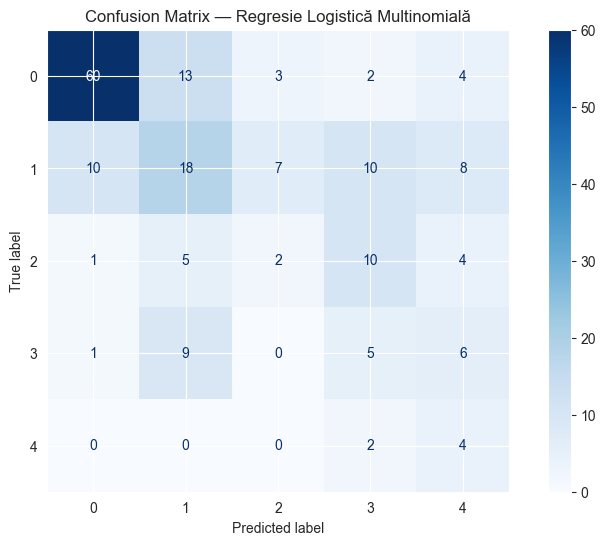

In [34]:
model_multi = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",   # compensează dezechilibrul claselor
    solver="lbfgs",
    random_state=RANDOM_STATE
)

model_multi.fit(X_train_m_scaled, y_train_m)
pred_multi = model_multi.predict(X_test_m_scaled)

acc_multi = accuracy_score(y_test_m, pred_multi)
f1_multi = f1_score(y_test_m, pred_multi, average="macro")

print(classification_report(y_test_m, pred_multi, zero_division=0))
print(f"Accuracy multiclasă: {acc_multi:.3f}")
print(f"F1 macro multiclasă: {f1_multi:.3f}")

ConfusionMatrixDisplay.from_predictions(y_test_m, pred_multi, cmap="Blues")
plt.title("Confusion Matrix — Regresie Logistică Multinomială")
plt.show()

Performanța modelului multiclasă este vizibil mai slabă decât a celui binar. Concret:
- Accuracy (0.48) — un model „bun" pentru 5 clase nedezechilibrate ar avea peste 60%.
- F1 macro scăzut (0.34) — confirmă că modelul are dificultăți în special pe clasele rare (3 și 4).
- Matricea de confuzie arată predicții greșite frecvente între clase adiacente (ex: 1 vs 2, 2 vs 3) — modelul nu poate stabili exact gradul de severitate al bolii pacienților.

### 14.1 Comparație cu modelele ML pe multiclasă

In [35]:
# Comparăm regresia multinomială cu RF și GB pe multiclasă
modele_multi = {
    "Regresie Logistica Multinomiala": LogisticRegression(
        max_iter=3000, class_weight="balanced",
        solver="lbfgs", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=4,
        class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05,
        max_depth=3, random_state=RANDOM_STATE
    )
}

rezultate_m = []

for nume, model in modele_multi.items():
    if "Logistica" in nume:
        model.fit(X_train_m_scaled, y_train_m)
        pred = model.predict(X_test_m_scaled)
    else:
        model.fit(X_train_m, y_train_m)
        pred = model.predict(X_test_m)

    rezultate_m.append({
        "Model": nume,
        "Accuracy": round(accuracy_score(y_test_m, pred), 3),
        "F1 macro": round(f1_score(y_test_m, pred, average="macro"), 3),
        "F1 weighted": round(f1_score(y_test_m, pred, average="weighted"), 3),
    })

rezultate_multi = pd.DataFrame(rezultate_m).sort_values("F1 macro", ascending=False)
display(rezultate_multi)

,Model,Accuracy,F1 macro,F1 weighted
1,Random Forest,0.582,0.411,0.584
2,Gradient Boosting,0.582,0.360,0.566
0,Regresie Logistica Multinomiala,0.484,0.343,0.498


Pe multiclasă, modelele ML (RF, GB) tind să bată regresia multinomială, dar diferențele sunt modeste. Performanța absolută rămâne însă slabă pentru toate cele 3 modele — confirmă că problema multiclasă este dificilă pe acest dataset.

---

# 15. Concluzii finale

## De ce am făcut tot acest efort?

Am construit un sistem de predicție a bolii cardiace care răspunde la două întrebări distincte ale unui clinician:
1. **„Are pacientul boală?"** (binar) — pentru screening rapid
2. **„Cât de severă e?"** (multiclasă) — pentru triere și decizia de tratament

## Ce am descoperit interesant în EDA?

- **Paradoxul colesterolului:** deși mediatizat ca principal factor de risc, colesterolul singur are corelație foarte slabă cu severitatea bolii în acest dataset. Acest lucru contrazice intuiția populară și sugerează că **combinațiile de factori** contează mai mult decât valorile individuale.
- **Indicatorii de efort domină:** cele mai puternice corelații cu boala sunt cu variabilele măsurate la efort: `st_depression` (+0.41) și `max_heart_rate` (−0.35). Asta înseamnă că **testele la efort sunt mai informative decât analizele de sânge** de rutină.
- **Pragul vârstei de 50 de ani:** este punctul în care numărul bolnavilor depășește numărul sănătoșilor.
- **Pacienții asimptomatici sunt cei mai bolnavi:** contraintuitiv, durerea „asymptomatic" se asociază cu cel mai mare procent de boală — explicație: boala „tăcută" și avansată.

## Ce features influențează y-ul?

Conform regresiei logistice (interpretare directă prin odds ratios) și a importanței features-urilor din modelele ML, factorii dominanți sunt:
1. **`st_depression`** — semnal de ischemie la efort (cel mai puternic predictor)
2. **`chest_pain_type`** — tipul „asymptomatic" este factor de risc
3. **`max_heart_rate`** — invers proporțional cu severitatea (factor protector)
4. **`exercise_angina`** — angină la efort = semnal de alarmă
5. **`major_vessels`** — numărul de vase afectate la fluoroscopie
6. **`sex`** (Male) și **`age`** — factori de risc demografici clasici

## Cum schimbă situația curentă faptul că avem un model?

- **Screening (binar):** Un spital poate folosi modelul ca pas de început pentru descoperirea unei boli — pacienții cu probabilitate > 50% sunt trimiși la teste suplimentare. Cu un AUC > 0.85, modelul ratează puține cazuri reale.
- **Triere (multiclasă):** Modelul este mai puțin fiabil aici, dar poate fi util ca semnal — un pacient clasificat în grupul „severitate 3-4" merită investigații prioritare, chiar dacă diagnosticul exact se face doar prin teste suplimentare.
- **Educație medicală:** Coeficienții regresiei logistice oferă o ierarhie clară a factorilor de risc — utilă în comunicarea cu pacienții și în programe de prevenție.

## Trade-off interpretabilitate vs. performanță

Regresia logistică oferă coeficienți direct interpretabili (cu odds ratios pe care un medic îi poate citi), în timp ce modelele ML câștigă uneori câteva procente la F1 dar pierd din transparență. Pentru un context medical reglementat (FDA, EMA), unde modelul trebuie justificat în fața autorităților, preferăm regresia logistică atunci când performanța este suficientă. În acest proiect, diferența între regresia logistică și modelele ML pe partea binară este mică — deci alegerea regresiei este pe deplin justificată.

## Limitări

- Datele sunt din **UCI Heart Disease** (clasice, dar mai vechi) — un model production-ready ar trebui validat pe date contemporane și pe populații diverse.
- Clasele 3 și 4 (severitate mare) sunt subreprezentate — performanța pe multiclasă rămâne limitată.
- Nu am inclus variabile genetice sau de istoric familial, care în practică contează mult.
- **Label Encoding** introduce ordine artificială pentru variabilele nominale; o îmbunătățire ar fi folosirea OneHotEncoding cu eliminarea unei categorii de referință.